# Options Strategy Recommendation and Optimisation System
## Notebook 2 - Market Feature Engineering

This notebook transforms the cleaned data from Notebook 1 into explainable market and option features for the later intelligent-reasoning and optimisation stages.

### Main outputs
1. Underlying trend and momentum features.
2. Historical-versus-implied volatility features.
3. Expected-move ranges for every selected expiry.
4. DTE and option moneyness categories.
5. A transparent 0-100 liquidity score.
6. A machine-readable feature snapshot for the rule engine and knowledge graph.

## Scope and reasoning role

Notebook 1 collected and validated market data. This notebook performs **knowledge discovery** by converting raw observations into higher-level concepts such as `bullish trend`, `elevated implied volatility`, `at-the-money`, `medium DTE` and `good liquidity`.

No strategy is recommended here. Keeping feature calculation separate from business rules makes the later recommendation explainable and prevents the user's bullish/bearish belief from changing the observed market facts.

## 1. Environment setup

This notebook uses only the files produced by Notebook 1. If needed, install the packages once with: `pip install pandas numpy matplotlib`.

In [4]:
from __future__ import annotations

import json
import math
import re
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__}")

Python: 3.9.23 | pandas: 2.3.2


## 2. Configuration and Notebook 1 inputs

Use a ticker that has completed Notebook 1.

In [6]:
TICKER = "CRM"


In [7]:
NOTEBOOK1_ROOT = Path("outputs/notebook_01")
NOTEBOOK2_ROOT = Path("outputs/notebook_02")
ATM_BAND_PCT = 0.02
MIN_CANDIDATE_LIQUIDITY_SCORE = 40.0

def validate_run_settings(ticker: str) -> str:
    clean_ticker = ticker.strip().upper().replace(".", "-")
    if not clean_ticker or not re.fullmatch(r"[A-Z0-9^=-]{1,15}", clean_ticker):
        raise ValueError("Ticker is empty or contains unsupported characters.")
    return clean_ticker

ticker = validate_run_settings(TICKER)
NOTEBOOK1_DIR = NOTEBOOK1_ROOT / ticker
OUTPUT_DIR = NOTEBOOK2_ROOT / ticker
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

input_paths = {
    "history": NOTEBOOK1_DIR / "history_features.csv",
    "options": NOTEBOOK1_DIR / "option_universe.csv",
    "snapshot": NOTEBOOK1_DIR / "market_snapshot.json",
}
input_paths


{'history': WindowsPath('outputs/notebook_01/CRM/history_features.csv'),
 'options': WindowsPath('outputs/notebook_01/CRM/option_universe.csv'),
 'snapshot': WindowsPath('outputs/notebook_01/CRM/market_snapshot.json')}

In [8]:
HISTORY_REQUIRED_COLUMNS = {"Date", "Open", "High", "Low", "Close", "Volume"}
OPTION_REQUIRED_COLUMNS = {
    "contractSymbol", "option_type", "expiry", "dte", "strike",
    "spot_price", "mid_price", "bid", "ask", "volume",
    "openInterest", "impliedVolatility", "strike_to_spot",
    "bid_ask_spread_pct"
}

def require_columns(frame: pd.DataFrame, required: set[str], name: str) -> None:
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

def load_notebook1_outputs(paths: dict[str, Path]) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    missing_files = [str(path) for path in paths.values() if not path.exists()]
    if missing_files:
        raise FileNotFoundError(
            "Notebook 1 outputs were not found for this ticker. Missing: "
            + ", ".join(missing_files)
        )

    history = pd.read_csv(paths["history"], parse_dates=["Date"])
    options = pd.read_csv(paths["options"])
    with paths["snapshot"].open("r", encoding="utf-8") as file:
        snapshot = json.load(file)

    require_columns(history, HISTORY_REQUIRED_COLUMNS, "History dataset")
    require_columns(options, OPTION_REQUIRED_COLUMNS, "Option dataset")

    if snapshot.get("request", {}).get("ticker") != ticker:
        raise ValueError("Notebook 1 snapshot does not match the configured ticker.")
    return history.sort_values("Date").reset_index(drop=True), options.copy(), snapshot


In [9]:
history_input, options_input, notebook1_snapshot = load_notebook1_outputs(input_paths)
print(f"Loaded {len(history_input):,} historical rows and {len(options_input):,} option contracts.")
display(history_input.tail(3))
display(options_input.head(3))

Loaded 501 historical rows and 125 option contracts.


,Date,Adj Close,Close,High,Low,Open,Volume,daily_return,log_return,sma_20,sma_50,realized_vol_20,realized_vol_60,rsi_14,momentum_20,trend_state
498,2026-08-19,206.0900,206.0900,207.9500,194.2100,194.2100,17843600,0.0507,0.0495,187.8655,173.2284,0.5102,0.5145,68.9460,0.2644,above_sma50
499,2026-08-20,205.4300,205.4300,207.8800,203.0000,205.2200,11482300,-0.0032,-0.0032,190.2905,173.8300,0.4793,0.5144,66.6408,0.3091,above_sma50
500,2026-08-21,209.1700,209.1700,211.0700,204.7300,205.5800,9612800,0.0182,0.0180,192.5660,174.5950,0.4678,0.5149,67.5537,0.2781,above_sma50


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,option_type,expiry,dte,mid_price,bid_ask_spread,bid_ask_spread_pct,spot_price,strike_to_spot,moneyness_pct,absolute_moneyness_pct,intrinsic_value,time_value,ttm_years,delta,gamma,theta_day,vega_1pct,liquidity_pass,valid_iv
0,CRM260918C00220000,2026-08-21 19:59:17+00:00,220.0000,7.3000,0.0000,0.0000,0.0000,0.0000,"1,568.0000",7611,0.0313,False,REGULAR,USD,call,2026-09-18,25,7.3000,NaN,NaN,209.1700,1.0518,0.0518,0.0518,0.0000,7.3000,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True
1,CRM260918C00230000,2026-08-21 19:59:52+00:00,230.0000,4.4000,0.0000,0.0000,0.0000,0.0000,"1,270.0000",6266,0.0625,False,REGULAR,USD,call,2026-09-18,25,4.4000,NaN,NaN,209.1700,1.0996,0.0996,0.0996,0.0000,4.4000,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True
2,CRM260918C00240000,2026-08-21 19:57:43+00:00,240.0000,2.7000,0.0000,0.0000,0.0000,0.0000,221.0000,4645,0.1250,False,REGULAR,USD,call,2026-09-18,25,2.7000,NaN,NaN,209.1700,1.1474,0.1474,0.1474,0.0000,2.7000,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True


## 3. Underlying-price and trend features

The trend score combines four transparent observations: price versus SMA20, price versus SMA50, SMA20 versus SMA50, and MACD versus its signal line. Each observation contributes +1 or -1 before conversion to a 0-100 score.

In [11]:
def calculate_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    average_gain = delta.clip(lower=0).ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    average_loss = (-delta.clip(upper=0)).ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    relative_strength = average_gain / average_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + relative_strength))
    return rsi.where(average_loss.ne(0), 100.0)

def add_underlying_features(history: pd.DataFrame) -> pd.DataFrame:
    result = history.copy().sort_values("Date").reset_index(drop=True)
    for column in ["Open", "High", "Low", "Close", "Volume"]:
        result[column] = pd.to_numeric(result[column], errors="coerce")

    close = result["Close"]
    previous_close = close.shift(1)
    true_range = pd.concat(
        [(result["High"] - result["Low"]).abs(),
         (result["High"] - previous_close).abs(),
         (result["Low"] - previous_close).abs()],
        axis=1
    ).max(axis=1)

    result["daily_return"] = close.pct_change()
    result["log_return"] = np.log(close / close.shift(1))
    for window in [20, 50, 200]:
        result[f"sma_{window}"] = close.rolling(window).mean()
    result["ema_12"] = close.ewm(span=12, adjust=False).mean()
    result["ema_26"] = close.ewm(span=26, adjust=False).mean()
    result["macd"] = result["ema_12"] - result["ema_26"]
    result["macd_signal"] = result["macd"].ewm(span=9, adjust=False).mean()
    result["rsi_14"] = calculate_rsi(close, 14)
    result["atr_14"] = true_range.rolling(14).mean()
    result["momentum_20"] = close.pct_change(20)
    result["historical_vol_20"] = result["log_return"].rolling(20).std() * np.sqrt(252)
    result["historical_vol_60"] = result["log_return"].rolling(60).std() * np.sqrt(252)

    components = pd.DataFrame({
        "price_vs_sma20": np.where(close >= result["sma_20"], 1, -1),
        "price_vs_sma50": np.where(close >= result["sma_50"], 1, -1),
        "sma20_vs_sma50": np.where(result["sma_20"] >= result["sma_50"], 1, -1),
        "macd_vs_signal": np.where(result["macd"] >= result["macd_signal"], 1, -1),
    }, index=result.index)
    insufficient = result[["sma_20", "sma_50", "macd_signal"]].isna().any(axis=1)
    result["trend_raw_score"] = components.sum(axis=1).where(~insufficient)
    result["trend_score"] = ((result["trend_raw_score"] + 4) / 8 * 100).clip(0, 100)
    result["trend_label"] = pd.cut(
        result["trend_score"], bins=[-np.inf, 25, 40, 60, 75, np.inf],
        labels=["strong_bearish", "bearish", "neutral", "bullish", "strong_bullish"],
        include_lowest=True
    ).astype("object")
    return result

underlying_features = add_underlying_features(history_input)
latest_underlying = underlying_features.dropna(subset=["Close"]).iloc[-1]
display(underlying_features.tail())

,Date,Adj Close,Close,High,Low,Open,Volume,daily_return,log_return,sma_20,sma_50,realized_vol_20,realized_vol_60,rsi_14,momentum_20,trend_state,sma_200,ema_12,ema_26,macd,macd_signal,atr_14,historical_vol_20,historical_vol_60,trend_raw_score,trend_score,trend_label
496,2026-08-17,190.9700,190.9700,194.9400,189.9100,193.8300,14378800,-0.0267,-0.0271,184.4070,172.5480,0.5282,0.5061,55.7358,0.0989,above_sma50,201.8865,191.2612,184.2117,7.0495,6.5420,8.1221,0.5282,0.5061,4.0000,100.0000,strong_bullish
497,2026-08-18,196.1400,196.1400,199.4100,193.2300,194.0900,14152900,0.0271,0.0267,185.7110,172.7576,0.5241,0.5066,59.1431,0.1534,above_sma50,201.6099,192.0118,185.0953,6.9165,6.6169,8.1050,0.5241,0.5066,4.0000,100.0000,strong_bullish
498,2026-08-19,206.0900,206.0900,207.9500,194.2100,194.2100,17843600,0.0507,0.0495,187.8655,173.2284,0.5102,0.5145,64.7648,0.2644,above_sma50,201.3571,194.1777,186.6504,7.5272,6.7990,8.1950,0.5102,0.5145,4.0000,100.0000,strong_bullish
499,2026-08-20,205.4300,205.4300,207.8800,203.0000,205.2200,11482300,-0.0032,-0.0032,190.2905,173.8300,0.4793,0.5144,64.1344,0.3091,above_sma50,201.0822,195.9088,188.0415,7.8673,7.0126,8.0136,0.4793,0.5144,4.0000,100.0000,strong_bullish
500,2026-08-21,209.1700,209.1700,211.0700,204.7300,205.5800,9612800,0.0182,0.0180,192.5660,174.5950,0.4678,0.5149,66.1453,0.2781,above_sma50,200.8214,197.9490,189.6066,8.3424,7.2786,7.7750,0.4678,0.5149,4.0000,100.0000,strong_bullish


In [12]:
observed_direction = (
    "bullish" if latest_underlying["trend_score"] > 60
    else "bearish" if latest_underlying["trend_score"] < 40
    else "neutral"
)

trend_summary = pd.DataFrame([{
    "ticker": ticker,
    "current_price": latest_underlying["Close"],
    "sma_20": latest_underlying["sma_20"],
    "sma_50": latest_underlying["sma_50"],
    "sma_200": latest_underlying["sma_200"],
    "rsi_14": latest_underlying["rsi_14"],
    "macd": latest_underlying["macd"],
    "macd_signal": latest_underlying["macd_signal"],
    "trend_score": latest_underlying["trend_score"],
    "trend_label": latest_underlying["trend_label"],
    "observed_direction": observed_direction,
}])
display(trend_summary.T.rename(columns={0: "value"}))


,value
ticker,CRM
current_price,209.1700
sma_20,192.5660
sma_50,174.5950
sma_200,200.8214
rsi_14,66.1453
macd,8.3424
macd_signal,7.2786
trend_score,100.0000
trend_label,strong_bullish


## 4. Option moneyness, DTE and liquidity features

The liquidity score is intentionally interpretable:

- 45% open-interest percentile;
- 25% volume percentile; and
- 30% bid-ask tightness percentile.

Scores are calculated within each expiry and option type so contracts are compared with relevant peers.

In [14]:
def classify_moneyness(option_type: str, strike_to_spot: float) -> str:
    if not np.isfinite(strike_to_spot):
        return "unknown"
    if 1 - ATM_BAND_PCT <= strike_to_spot <= 1 + ATM_BAND_PCT:
        return "atm"
    if option_type == "call":
        if strike_to_spot <= 0.90:
            return "deep_itm"
        if strike_to_spot < 1 - ATM_BAND_PCT:
            return "itm"
        if strike_to_spot <= 1.10:
            return "otm"
        return "deep_otm"
    if strike_to_spot >= 1.10:
        return "deep_itm"
    if strike_to_spot > 1 + ATM_BAND_PCT:
        return "itm"
    if strike_to_spot >= 0.90:
        return "otm"
    return "deep_otm"

def percentile_score(series: pd.Series, higher_is_better: bool) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if len(numeric) == 1:
        return pd.Series([50.0], index=series.index)
    ranks = numeric.rank(method="average", pct=True, ascending=True)
    scores = ranks * 100 if higher_is_better else (1 - ranks) * 100
    return scores.fillna(0).clip(0, 100)

def add_option_features(options: pd.DataFrame) -> pd.DataFrame:
    result = options.copy()
    numeric_columns = [
        "dte", "strike", "spot_price", "mid_price", "bid", "ask",
        "volume", "openInterest", "impliedVolatility", "strike_to_spot",
        "bid_ask_spread_pct", "delta", "gamma", "theta_day", "vega_1pct"
    ]
    for column in numeric_columns:
        if column in result.columns:
            result[column] = pd.to_numeric(result[column], errors="coerce")

    result["expiry"] = pd.to_datetime(result["expiry"]).dt.strftime("%Y-%m-%d")
    result["moneyness_category"] = result.apply(
        lambda row: classify_moneyness(row["option_type"], row["strike_to_spot"]), axis=1
    )
    result["dte_bucket"] = pd.cut(
        result["dte"], bins=[0, 30, 60, 90, np.inf],
        labels=["short_1_30", "medium_31_60", "long_61_90", "very_long_91_plus"],
        include_lowest=True
    ).astype("object")
    result["spread_quality"] = pd.cut(
        result["bid_ask_spread_pct"], bins=[-np.inf, 0.05, 0.10, 0.20, np.inf],
        labels=["excellent", "good", "fair", "poor"]
    ).astype("object")

    peer_groups = result.groupby(["expiry", "option_type"], group_keys=False)
    result["open_interest_score"] = peer_groups["openInterest"].transform(
        lambda values: percentile_score(values.fillna(0), True)
    )
    result["volume_score"] = peer_groups["volume"].transform(
        lambda values: percentile_score(values.fillna(0), True)
    )
    result["tight_spread_score"] = peer_groups["bid_ask_spread_pct"].transform(
        lambda values: percentile_score(values, False)
    )
    result["liquidity_score"] = (
        0.45 * result["open_interest_score"]
        + 0.25 * result["volume_score"]
        + 0.30 * result["tight_spread_score"]
    ).clip(0, 100)
    result["liquidity_band"] = pd.cut(
        result["liquidity_score"], bins=[-np.inf, 25, 50, 75, np.inf],
        labels=["poor", "fair", "good", "excellent"], include_lowest=True
    ).astype("object")
    result["candidate_quality_pass"] = (
        result["liquidity_score"].ge(MIN_CANDIDATE_LIQUIDITY_SCORE)
        & result["mid_price"].gt(0)
        & result["impliedVolatility"].between(0.01, 5.0)
        & result["dte"].gt(0)
    )
    return result.sort_values(["expiry", "option_type", "strike"]).reset_index(drop=True)

option_features = add_option_features(options_input)
display(option_features.head())

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,option_type,expiry,dte,mid_price,bid_ask_spread,bid_ask_spread_pct,spot_price,strike_to_spot,moneyness_pct,absolute_moneyness_pct,intrinsic_value,time_value,ttm_years,delta,gamma,theta_day,vega_1pct,liquidity_pass,valid_iv,moneyness_category,dte_bucket,spread_quality,open_interest_score,volume_score,tight_spread_score,liquidity_score,liquidity_band,candidate_quality_pass
0,CRM260918C00220000,2026-08-21 19:59:17+00:00,220.0000,7.3000,0.0000,0.0000,0.0000,0.0000,"1,568.0000",7611,0.0313,False,REGULAR,USD,call,2026-09-18,25,7.3000,NaN,NaN,209.1700,1.0518,0.0518,0.0518,0.0000,7.3000,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True,otm,short_1_30,NaN,100.0000,100.0000,0.0000,70.0000,good,True
1,CRM260918C00230000,2026-08-21 19:59:52+00:00,230.0000,4.4000,0.0000,0.0000,0.0000,0.0000,"1,270.0000",6266,0.0625,False,REGULAR,USD,call,2026-09-18,25,4.4000,NaN,NaN,209.1700,1.0996,0.0996,0.0996,0.0000,4.4000,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True,otm,short_1_30,NaN,90.0000,90.0000,0.0000,63.0000,good,True
2,CRM260918C00240000,2026-08-21 19:57:43+00:00,240.0000,2.7000,0.0000,0.0000,0.0000,0.0000,221.0000,4645,0.1250,False,REGULAR,USD,call,2026-09-18,25,2.7000,NaN,NaN,209.1700,1.1474,0.1474,0.1474,0.0000,2.7000,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True,deep_otm,short_1_30,NaN,70.0000,60.0000,0.0000,46.5000,fair,True
3,CRM260918C00250000,2026-08-21 19:59:41+00:00,250.0000,1.5700,0.0000,0.0000,0.0000,0.0000,201.0000,5391,0.1250,False,REGULAR,USD,call,2026-09-18,25,1.5700,NaN,NaN,209.1700,1.1952,0.1952,0.1952,0.0000,1.5700,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True,deep_otm,short_1_30,NaN,80.0000,50.0000,0.0000,48.5000,fair,True
4,CRM260918C00260000,2026-08-21 19:57:43+00:00,260.0000,0.9500,0.0000,0.0000,0.0000,0.0000,24.0000,2091,0.1250,False,REGULAR,USD,call,2026-09-18,25,0.9500,NaN,NaN,209.1700,1.2430,0.2430,0.2430,0.0000,0.9500,0.0685,0.0000,0.0000,-0.0000,0.0000,False,True,deep_otm,short_1_30,NaN,50.0000,20.0000,0.0000,27.5000,fair,False


## 5. Implied volatility and expected move

For each expiry, at-the-money IV is estimated from contracts within 2% of spot. When no contract falls inside that band, the nearest call and put are used. The one-standard-deviation expected move is:

$$\text{Expected Move} = S_0 \times \sigma_{ATM} \times \sqrt{\frac{DTE}{365}}$$

In [16]:
def choose_atm_contracts(group: pd.DataFrame) -> pd.DataFrame:
    inside_band = group.loc[(group["strike_to_spot"] - 1).abs() <= ATM_BAND_PCT]
    if not inside_band.empty:
        return inside_band
    nearest_indices = (
        group.assign(distance=(group["strike_to_spot"] - 1).abs())
        .sort_values("distance")
        .groupby("option_type", as_index=False)
        .head(1)
        .index
    )
    return group.loc[nearest_indices]

def volatility_regime(iv_to_hv_ratio: float) -> str:
    if not np.isfinite(iv_to_hv_ratio):
        return "unknown"
    if iv_to_hv_ratio < 0.80:
        return "low_iv_relative_to_hv"
    if iv_to_hv_ratio <= 1.20:
        return "balanced_iv_hv"
    if iv_to_hv_ratio <= 1.50:
        return "elevated_iv"
    return "high_iv"

def build_expiry_features(options: pd.DataFrame, historical_vol_20: float) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for (expiry, dte), group in options.groupby(["expiry", "dte"]):
        atm = choose_atm_contracts(group)
        spot = float(group["spot_price"].median())
        atm_iv = float(atm["impliedVolatility"].median())
        expected_move_pct = atm_iv * math.sqrt(float(dte) / 365)
        expected_move = spot * expected_move_pct
        iv_hv_ratio = atm_iv / historical_vol_20 if historical_vol_20 > 0 else np.nan
        rows.append({
            "expiry": expiry,
            "dte": int(dte),
            "dte_bucket": group["dte_bucket"].mode().iloc[0],
            "spot_price": spot,
            "atm_contract_count": int(len(atm)),
            "atm_implied_volatility": atm_iv,
            "historical_vol_20": historical_vol_20,
            "iv_to_hv_ratio": iv_hv_ratio,
            "volatility_regime": volatility_regime(iv_hv_ratio),
            "expected_move_pct": expected_move_pct,
            "expected_move": expected_move,
            "expected_lower_price": max(0.0, spot - expected_move),
            "expected_upper_price": spot + expected_move,
            "median_liquidity_score": float(group["liquidity_score"].median()),
            "candidate_contract_count": int(group["candidate_quality_pass"].sum()),
        })
    return pd.DataFrame(rows).sort_values("dte").reset_index(drop=True)

historical_vol_20 = float(latest_underlying["historical_vol_20"])
expiry_features = build_expiry_features(option_features, historical_vol_20)
option_features = option_features.merge(
    expiry_features[["expiry", "dte", "expected_lower_price", "expected_upper_price", "volatility_regime"]],
    on=["expiry", "dte"], how="left", validate="many_to_one"
)
option_features["strike_inside_expected_range"] = option_features["strike"].between(
    option_features["expected_lower_price"], option_features["expected_upper_price"]
)
display(expiry_features)

,expiry,dte,dte_bucket,spot_price,atm_contract_count,atm_implied_volatility,historical_vol_20,iv_to_hv_ratio,volatility_regime,expected_move_pct,expected_move,expected_lower_price,expected_upper_price,median_liquidity_score,candidate_contract_count
0,2026-09-18,25,short_1_30,209.1700,2,0.0313,0.4678,0.0668,low_iv_relative_to_hv,0.0082,1.7112,207.4588,210.8812,38.6250,15
1,2026-09-25,32,medium_31_60,209.1700,1,0.0156,0.4678,0.0334,low_iv_relative_to_hv,0.0046,0.9683,208.2017,210.1383,39.2500,16
2,2026-10-02,39,medium_31_60,209.1700,1,0.0156,0.4678,0.0334,low_iv_relative_to_hv,0.0051,1.0690,208.1010,210.2390,40.4453,16
3,2026-10-16,53,medium_31_60,209.1700,2,0.0313,0.4678,0.0668,low_iv_relative_to_hv,0.0119,2.4916,206.6784,211.6616,38.2500,14


## 6. Construct the feature snapshot

The snapshot keeps observed market direction independent from the user's outlook. Notebook 3 compares the observed direction with each bullish or bearish request and records the alignment in its reasoning trace.

In [18]:
def finite_or_none(value: Any) -> float | None:
    try:
        numeric = float(value)
        return numeric if math.isfinite(numeric) else None
    except (TypeError, ValueError):
        return None

def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return finite_or_none(value)
    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()
    if pd.isna(value):
        return None
    return value

feature_snapshot = json_safe({
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker},
    "underlying_features": {
        "as_of_date": latest_underlying["Date"],
        "current_price": latest_underlying["Close"],
        "sma_20": latest_underlying["sma_20"],
        "sma_50": latest_underlying["sma_50"],
        "sma_200": latest_underlying["sma_200"],
        "rsi_14": latest_underlying["rsi_14"],
        "atr_14": latest_underlying["atr_14"],
        "momentum_20": latest_underlying["momentum_20"],
        "historical_vol_20": latest_underlying["historical_vol_20"],
        "historical_vol_60": latest_underlying["historical_vol_60"],
        "trend_score": latest_underlying["trend_score"],
        "trend_label": latest_underlying["trend_label"],
        "observed_direction": observed_direction,
    },
    "expiry_features": expiry_features.to_dict(orient="records"),
    "option_feature_summary": {
        "total_contracts": len(option_features),
        "quality_contracts": int(option_features["candidate_quality_pass"].sum()),
        "median_liquidity_score": option_features["liquidity_score"].median(),
        "moneyness_counts": option_features["moneyness_category"].value_counts().to_dict(),
        "liquidity_band_counts": option_features["liquidity_band"].value_counts().to_dict(),
    },
    "feature_definitions": {
        "atm_band_pct": ATM_BAND_PCT,
        "minimum_candidate_liquidity_score": MIN_CANDIDATE_LIQUIDITY_SCORE,
        "liquidity_weights": {"open_interest": 0.45, "volume": 0.25, "tight_spread": 0.30},
        "expected_move_model": "spot * ATM implied volatility * sqrt(DTE / 365)",
    },
})
feature_snapshot

{'generated_at_utc': '2026-08-24T13:23:27.955173+00:00',
 'request': {'ticker': 'CRM'},
 'underlying_features': {'as_of_date': '2026-08-21T00:00:00',
  'current_price': 209.1699981689453,
  'sma_20': 192.56600112915038,
  'sma_50': 174.595,
  'sma_200': 200.8213507080078,
  'rsi_14': 66.14526817157142,
  'atr_14': 7.774999346051904,
  'momentum_20': 0.27807646027428534,
  'historical_vol_20': 0.4677746644402869,
  'historical_vol_60': 0.5148811426805425,
  'trend_score': 100.0,
  'trend_label': 'strong_bullish',
  'observed_direction': 'bullish'},
 'expiry_features': [{'expiry': '2026-09-18',
   'dte': 25,
   'dte_bucket': 'short_1_30',
   'spot_price': 209.1699981689453,
   'atm_contract_count': 2,
   'atm_implied_volatility': 0.0312596875,
   'historical_vol_20': 0.4677746644402869,
   'iv_to_hv_ratio': 0.06682638004220173,
   'volatility_regime': 'low_iv_relative_to_hv',
   'expected_move_pct': 0.008181034125097134,
   'expected_move': 1.7112268929666468,
   'expected_lower_price': 

## 7. Feature-quality checks

In [20]:
spot_from_options = float(option_features["spot_price"].median())
spot_from_history = float(latest_underlying["Close"])
quality_checks = {
    "history_has_enough_rows_for_hv60": len(underlying_features) >= 60,
    "historical_volatility_is_positive": np.isfinite(historical_vol_20) and historical_vol_20 > 0,
    "history_and_option_spot_are_consistent": abs(spot_from_options / spot_from_history - 1) <= 0.05,
    "option_contracts_are_unique": not option_features["contractSymbol"].duplicated().any(),
    "both_option_types_are_available": set(option_features["option_type"]) == {"call", "put"},
    "liquidity_scores_are_bounded": bool(option_features["liquidity_score"].between(0, 100).all()),
    "at_least_one_quality_contract": bool(option_features["candidate_quality_pass"].any()),
    "expected_moves_are_positive": bool(expiry_features["expected_move"].gt(0).all()),
    "expiry_rows_are_unique": not expiry_features[["expiry", "dte"]].duplicated().any(),
}
feature_quality_report = pd.DataFrame(
    [{"check": name, "passed": bool(passed)} for name, passed in quality_checks.items()]
)
display(feature_quality_report)

failed_checks = feature_quality_report.loc[~feature_quality_report["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError(f"Feature-quality checks failed: {failed_checks}")
print("All feature-quality checks passed.")

,check,passed
0,history_has_enough_rows_for_hv60,True
1,historical_volatility_is_positive,True
2,history_and_option_spot_are_consistent,True
3,option_contracts_are_unique,True
4,both_option_types_are_available,True
5,liquidity_scores_are_bounded,True
6,at_least_one_quality_contract,True
7,expected_moves_are_positive,True
8,expiry_rows_are_unique,True


All feature-quality checks passed.


## 8. Feature visualisation

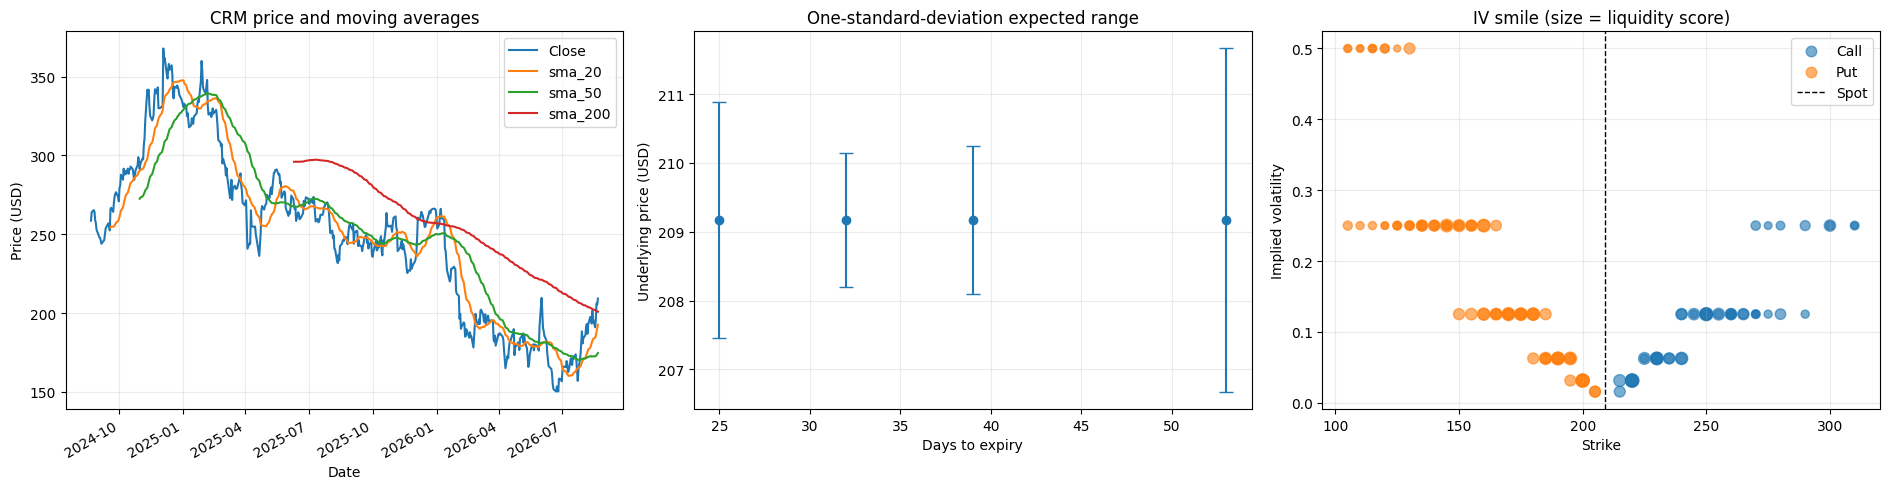

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

underlying_features.set_index("Date")[["Close", "sma_20", "sma_50", "sma_200"]].plot(
    ax=axes[0], title=f"{ticker} price and moving averages"
)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(alpha=0.25)

axes[1].errorbar(
    expiry_features["dte"], expiry_features["spot_price"],
    yerr=expiry_features["expected_move"], fmt="o", capsize=5
)
axes[1].set_title("One-standard-deviation expected range")
axes[1].set_xlabel("Days to expiry")
axes[1].set_ylabel("Underlying price (USD)")
axes[1].grid(alpha=0.25)

for option_type, group in option_features.groupby("option_type"):
    scatter = axes[2].scatter(
        group["strike"], group["impliedVolatility"],
        s=20 + group["liquidity_score"], alpha=0.60, label=option_type.title()
    )
axes[2].axvline(spot_from_history, color="black", linestyle="--", linewidth=1, label="Spot")
axes[2].set_title("IV smile (size = liquidity score)")
axes[2].set_xlabel("Strike")
axes[2].set_ylabel("Implied volatility")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Export engineered features

In [24]:
export_paths = {
    "underlying_features": OUTPUT_DIR / "underlying_features.csv",
    "option_features": OUTPUT_DIR / "option_features.csv",
    "expiry_features": OUTPUT_DIR / "expiry_features.csv",
    "feature_snapshot": OUTPUT_DIR / "feature_snapshot.json",
    "feature_quality_report": OUTPUT_DIR / "feature_quality_report.csv",
}
underlying_features.to_csv(export_paths["underlying_features"], index=False)
option_features.to_csv(export_paths["option_features"], index=False)
expiry_features.to_csv(export_paths["expiry_features"], index=False)
feature_quality_report.to_csv(export_paths["feature_quality_report"], index=False)
with export_paths["feature_snapshot"].open("w", encoding="utf-8") as file:
    json.dump(feature_snapshot, file, indent=2, allow_nan=False)

success_marker = OUTPUT_DIR / "_SUCCESS.json"
success_marker.write_text(json.dumps({
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "request": {"ticker": ticker},
    "notebook": "02_Market_Feature_Engineering.ipynb",
}, indent=2), encoding="utf-8")

export_manifest = pd.DataFrame([
    {"dataset": name, "path": str(path), "exists": path.exists()}
    for name, path in {**export_paths, "success_marker": success_marker}.items()
])
display(export_manifest)


,dataset,path,exists
0,underlying_features,outputs\notebook_02\CRM\underlying_features.csv,True
1,option_features,outputs\notebook_02\CRM\option_features.csv,True
2,expiry_features,outputs\notebook_02\CRM\expiry_features.csv,True
3,feature_snapshot,outputs\notebook_02\CRM\feature_snapshot.json,True
4,feature_quality_report,outputs\notebook_02\CRM\feature_quality_report...,True
5,success_marker,outputs\notebook_02\CRM\_SUCCESS.json,True


## 10. Key feature data dictionary

In [26]:
feature_dictionary = pd.DataFrame([
    ("trend_score", "0-100 score from four transparent trend observations"),
    ("trend_label", "Strong bearish, bearish, neutral, bullish or strong bullish"),
    ("observed_direction", "Direction implied by the engineered trend score"),
    ("historical_vol_20 / 60", "Annualised standard deviation of daily log returns"),
    ("atm_implied_volatility", "Median IV of contracts near the current price"),
    ("iv_to_hv_ratio", "ATM implied volatility divided by 20-day historical volatility"),
    ("volatility_regime", "Low, balanced, elevated or high IV relative to HV"),
    ("expected_move", "One-standard-deviation price move to expiry"),
    ("dte_bucket", "Short, medium, long or very-long time to expiry"),
    ("moneyness_category", "Deep ITM, ITM, ATM, OTM or deep OTM"),
    ("liquidity_score", "0-100 weighted peer score using OI, volume and spread"),
    ("candidate_quality_pass", "Contract passes minimum quality requirements for later candidate generation"),
], columns=["feature", "meaning"])
display(feature_dictionary)

,feature,meaning
0,trend_score,0-100 score from four transparent trend observ...
1,trend_label,"Strong bearish, bearish, neutral, bullish or s..."
2,observed_direction,Direction implied by the engineered trend score
3,historical_vol_20 / 60,Annualised standard deviation of daily log ret...
4,atm_implied_volatility,Median IV of contracts near the current price
5,iv_to_hv_ratio,ATM implied volatility divided by 20-day histo...
6,volatility_regime,"Low, balanced, elevated or high IV relative to HV"
7,expected_move,One-standard-deviation price move to expiry
8,dte_bucket,"Short, medium, long or very-long time to expiry"
9,moneyness_category,"Deep ITM, ITM, ATM, OTM or deep OTM"


## Notebook 2 completion criteria

Notebook 2 is complete when all nine feature-quality checks pass and five output files are created. The next stage can use these facts to build a knowledge graph and apply explainable rules that map bullish/bearish outlook, trend, volatility regime, DTE and liquidity to suitable option-strategy families.